<a href="https://colab.research.google.com/github/reenupalle/deepcodeguard/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Data Exploration (EDA)

**DeepCodeGuard**: deep learning-based vulnerability detection on the Devign / CodeXGLUE Defect Detection benchmark.

This notebook answers the questions we must settle before building any model:
1. Is the data clean (missing or empty functions)?
2. How balanced are the labels, per split and per project?
3. How long are the functions, and does length differ between secure and vulnerable code?
4. How many functions are too long for CodeBERT's 512-token limit?
5. Are there duplicate functions, and do any leak from train into validation/test?

## 0 · Setup
Clone the repo and download the dataset. Colab starts empty each session, so this cell always runs first.

In [1]:
!git clone -q https://github.com/reenupalle/deepcodeguard.git 2>/dev/null || (cd deepcodeguard && git pull -q)
%cd /content/deepcodeguard
!pip install -q datasets
!python src/deepcodeguard/data/download.py

/content/deepcodeguard
README.md: 100% 5.60k/5.60k [00:00<00:00, 7.88MB/s]

data/train-00000-of-00001.parquet: downloading bytes:  74% 13.2M/17.8M [00:01<00:00, 14.0MB/s,  855kB/s  ]
data/train-00000-of-00001.parquet: downloading bytes: 100% 17.7M/17.7M [00:01<00:00, 10.3MB/s, 1.67MB/s  ]
data/train-00000-of-00001.parquet: reconstructing file: 100% 17.8M/17.8M [00:01<00:00, 10.3MB/s, 1.71MB/s  ]

data/validation-00000-of-00001.parquet: downloading bytes:  13% 289k/2.21M [00:00<00:02, 643kB/s]
data/validation-00000-of-00001.parquet: downloading bytes: 100% 2.20M/2.20M [00:00<00:00, 4.02MB/s,  217kB/s  ]
data/validation-00000-of-00001.parquet: reconstructing file: 100% 2.21M/2.21M [00:00<00:00, 4.05MB/s,  219kB/s  ]

data/test-00000-of-00001.parquet: downloading bytes:  30% 658k/2.23M [00:00<00:00, 1.94MB/s]
data/test-00000-of-00001.parquet: downloading bytes: 100% 2.21M/2.21M [00:00<00:00, 5.84MB/s,  219kB/s  ]
data/test-00000-of-00001.parquet: reconstructing file: 100% 2.23M/2.23M [00:

## 1 · Load all three splits into one table
Each row is one C function. `target` = 1 means vulnerable, 0 means secure.

In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SPLITS = ["train", "validation", "test"]
df = pd.concat(
    [pd.read_json(f"data/raw/{s}.jsonl", lines=True).assign(split=s) for s in SPLITS],
    ignore_index=True,
)
df["target"] = df["target"].astype(int)
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {0: "#2a78d6", 1: "#eb6834"}   # blue = secure, orange = vulnerable
NAMES = {0: "Secure (0)", 1: "Vulnerable (1)"}
print(df.shape)
df.head()

(27318, 6)


,id,func,target,project,commit_id,split
0,0,static av_cold int vdadec_init(AVCodecContext ...,0,FFmpeg,973b1a6b9070e2bf17d17568cbaf4043ce931f51,train
1,1,static int transcode(AVFormatContext **output_...,0,FFmpeg,321b2a9ded0468670b7678b7c098886930ae16b2,train
2,2,"static void v4l2_free_buffer(void *opaque, uin...",0,FFmpeg,5d5de3eba4c7890c2e8077f5b4ae569671d11cf8,train
3,4,"int av_opencl_buffer_write(cl_mem dst_cl_buf, ...",0,FFmpeg,57d77b3963ce1023eaf5ada8cba58b9379405cc8,train
4,5,"static int r3d_read_rdvo(AVFormatContext *s, A...",1,FFmpeg,aba232cfa9b193604ed98f3fa505378d006b1b3b,train


## 2 · Data quality and label balance
We check for missing or empty code, then count labels per split and per source project (FFmpeg vs QEMU).

**Why it matters:** if the classes were heavily imbalanced, accuracy would be misleading. If one project is much more vulnerable than the other, a model could learn *which project* code comes from instead of *what makes it vulnerable*.

In [3]:
print("Missing values:\n", df.isna().sum(), "\n")
print("Empty functions:", (df["func"].str.strip() == "").sum(), "\n")
balance = pd.crosstab(df["split"], df["target"], margins=True).reindex(SPLITS + ["All"])
balance["% vulnerable"] = (100 * balance[1] / balance["All"]).round(1)
print(balance, "\n")
by_project = pd.crosstab(df["project"], df["target"], margins=True)
by_project["% vulnerable"] = (100 * by_project[1] / by_project["All"]).round(1)
print(by_project)

Missing values:
 id           0
func         0
target       0
project      0
commit_id    0
split        0
dtype: int64 

Empty functions: 0 

target          0      1    All  % vulnerable
split                                        
train       11836  10018  21854          45.8
validation   1545   1187   2732          43.4
test         1477   1255   2732          45.9
All         14858  12460  27318          45.6 

target       0      1    All  % vulnerable
project                                   
FFmpeg    4788   4981   9769          51.0
qemu     10070   7479  17549          42.6
All      14858  12460  27318          45.6


## 3 · Function length
We split code into simple tokens (identifiers, numbers, symbols) and look at the distribution.

**Why it matters:** it decides the maximum sequence length for the RNN and Transformer models. If vulnerable functions are systematically longer, length alone could be a shortcut feature, which we should report.

       n_lines   n_chars  n_tokens
count  27318.0   27318.0   27318.0
mean     113.0    2024.0     440.0
std      235.0    4531.0     898.0
min        2.0      26.0       7.0
50%       58.0     937.0     208.0
90%      244.0    4456.0     979.0
95%      356.0    6893.0    1516.0
99%      780.0   15127.0    3311.0
max     8131.0  142346.0   26766.0

Median by label:
         n_lines  n_tokens
target                   
0          56.0     193.0
1          62.0     227.0


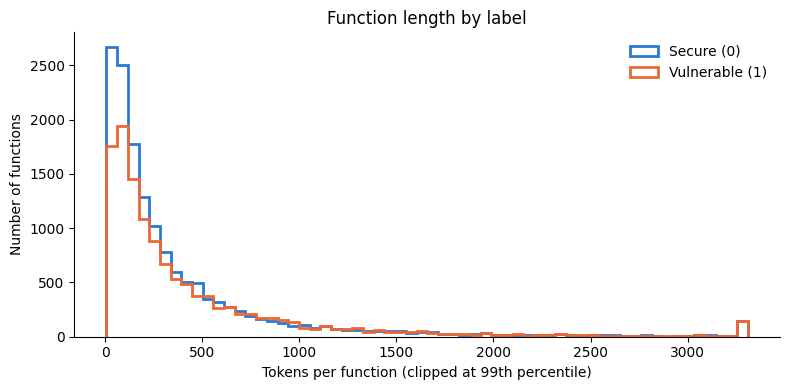

In [4]:
TOKEN_RE = re.compile(r"[A-Za-z_]\w*|\d+|\S")   # identifiers, numbers, single symbols
df["n_lines"] = df["func"].str.count("\n") + 1
df["n_chars"] = df["func"].str.len()
df["n_tokens"] = df["func"].map(lambda code: len(TOKEN_RE.findall(code)))
print(df[["n_lines", "n_chars", "n_tokens"]].describe(percentiles=[.5, .9, .95, .99]).round(0))
print("\nMedian by label:\n", df.groupby("target")[["n_lines", "n_tokens"]].median())

fig, ax = plt.subplots(figsize=(8, 4))
cap = df["n_tokens"].quantile(0.99)
for t in (0, 1):
    ax.hist(df.loc[df["target"] == t, "n_tokens"].clip(upper=cap), bins=60,
            histtype="step", linewidth=2, color=COLORS[t], label=NAMES[t])
ax.set_xlabel("Tokens per function (clipped at 99th percentile)")
ax.set_ylabel("Number of functions")
ax.set_title("Function length by label")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "token_length_by_label.png", dpi=150)
plt.show()

## 4 · CodeBERT truncation
CodeBERT can read at most 512 sub-word tokens. Anything longer gets cut off, and the vulnerable line might be in the part that is lost.

**Why it matters:** this fraction is an upper bound on how much information CodeBERT never sees. We'll cite it in error analysis ("token truncation").

In [ ]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("microsoft/codebert-base")
df["n_subwords"] = [len(ids) for ids in tok(df["func"].tolist(), add_special_tokens=True)["input_ids"]]
for limit in (256, 512):
    pct = 100 * (df["n_subwords"] > limit).mean()
    print(f"Functions longer than {limit} CodeBERT tokens: {pct:.1f}%")
print("\nBy label (% over 512):\n", (100 * df.groupby("target")["n_subwords"].apply(lambda s: (s > 512).mean())).round(1))

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

## 5 · Duplicates and train/test leakage
We normalise whitespace and look for identical functions.

**Why it matters:** a function that appears in both train and test lets a model score by memorising instead of generalising. Identical code with different labels is label noise. We keep the official split for comparability, but report these numbers.

In [ ]:
df["norm"] = df["func"].str.replace(r"\s+", " ", regex=True).str.strip()
dup_mask = df.duplicated("norm", keep=False)
print(f"Functions that have an exact duplicate (ignoring whitespace): {dup_mask.sum()}")

conflicts = df[dup_mask].groupby("norm")["target"].nunique()
print(f"Duplicate groups with CONFLICTING labels: {(conflicts > 1).sum()}")

train_code = set(df.loc[df["split"] == "train", "norm"])
for s in ("validation", "test"):
    leaked = df.loc[df["split"] == s, "norm"].isin(train_code)
    print(f"{s}: {leaked.sum()} functions also appear in train ({100 * leaked.mean():.1f}%)")

## 6 · Save a summary for the report

In [ ]:
summary = {
    "total_functions": len(df),
    "pct_vulnerable": round(100 * df["target"].mean(), 1),
    "median_tokens": int(df["n_tokens"].median()),
    "p95_tokens": int(df["n_tokens"].quantile(0.95)),
    "pct_over_512_codebert": round(100 * (df["n_subwords"] > 512).mean(), 1),
    "duplicate_functions": int(dup_mask.sum()),
    "test_overlap_with_train": int(df.loc[df["split"] == "test", "norm"].isin(train_code).sum()),
}
pd.Series(summary).to_json("reports/eda_summary.json", indent=2)
pd.Series(summary)

## Findings
_Fill this in after running: class balance, length stats, % truncated, number of duplicates/leaked functions, and what each means for the models._